In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from matplotlib.backends.backend_pdf import PdfPages

In [31]:
def line_plot(df, x, y, color, style, show):
    fig, ax = plt.subplots()
    sns.lineplot(data=df, x=x, y=y, hue=color, style=style, ax=ax, errorbar='sd', err_style="band")
    if y == 'silhouette average':
        plt.ylim(-0.3, 0.7)
    if y == 'lisi average':
        plt.ylim(1, 5)
    if 'adjusted rand index' in  y:
        plt.ylim(-0.2, 1)
    if show == True:
        plt.show()
    plt.close(fig)
    return fig

In [32]:
#dir = '/Users/memarchand/Project/Spatial-Transcriptomics/PDAC/clustering/work/cd/5ca52700255f26d1368324d735563b'
table_list = "['/Users/memarchand/Project/Spatial-Transcriptomics/PDAC/clustering/work/cd/5ca52700255f26d1368324d735563b/Visium_FFPE_V43T08-051_D_ref_final_table.csv', '/Users/memarchand/Project/Spatial-Transcriptomics/PDAC/clustering/work/cd/5ca52700255f26d1368324d735563b/Visium_FFPE_V43T08-051_D_sim_1_final_table.csv', '/Users/memarchand/Project/Spatial-Transcriptomics/PDAC/clustering/work/cd/5ca52700255f26d1368324d735563b/Visium_FFPE_V43T08-051_D_sim_2_final_table.csv']"

#Input
sample_name = 'Visium_FFPE_V43T08-051_D'
#table_list = "['../../nf_output/results/Visium_FFPE_V43T08-041_D_ref_final_table.csv', '../../nf_output/results/Visium_FFPE_V43T08-041_D_sim_1_final_table.csv', '../../nf_output/results/Visium_FFPE_V43T08-041_D_sim_2_final_table.csv', '../../nf_output/results/Visium_FFPE_V43T08-041_D_sim_3_final_table.csv', '../../nf_output/results/Visium_FFPE_V43T08-051_A_sim_4_final_table.csv']"

In [33]:
import ast
if isinstance(table_list, str):
    table_list = ast.literal_eval(table_list)

In [34]:
tables = []
for table_name in table_list:
    table = pd.read_csv(table_name)
    suffix = os.path.basename(table_name).replace(sample_name, '').strip('_')
    colname = suffix.replace('_final_table','').replace('.csv','')
    table['dataset'] = colname
    tables.append(table)
table_all = pd.concat(tables, ignore_index=True)

In [35]:
table_test = table_all.loc[table_all['refinement']==False,:]

In [36]:
output = f'{sample_name}_final_graphs.pdf'
metric_list = ['silhouette average', 'lisi average', 'adjusted rand index (sctype + uscore label)']

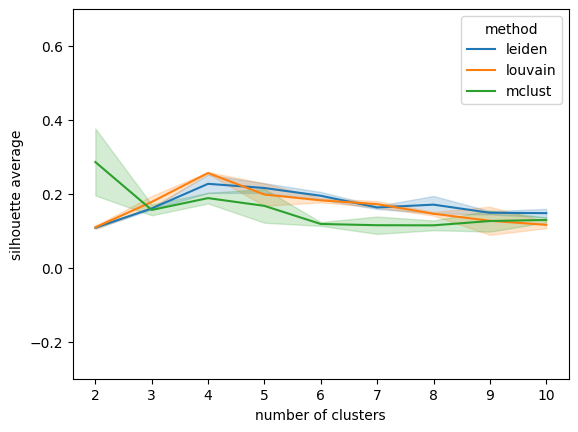

Figure(640x480)


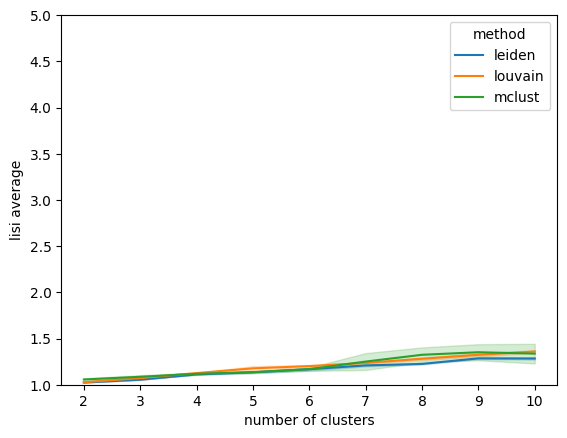

Figure(640x480)


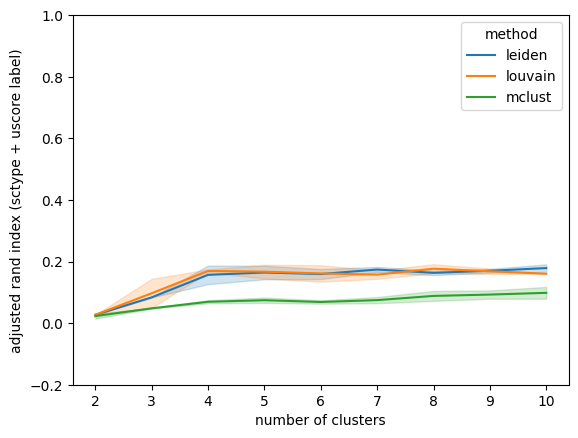

Figure(640x480)


In [37]:
with PdfPages(output) as pdf:
    for metric in metric_list:
        fig = line_plot(table_test, 'number of clusters', metric, 'method', None, show=True)
        print(fig)
        pdf.savefig(fig)

In [38]:
table_test

,method,refinement,number of clusters,silhouette average,lisi average,adjusted rand index (sctype + uscore label),dataset
0,leiden,False,10,0.160,1.294,0.188,ref
2,leiden,False,2,0.107,1.025,0.027,ref
4,leiden,False,3,0.161,1.056,0.083,ref
6,leiden,False,4,0.223,1.112,0.149,ref
8,leiden,False,5,0.207,1.146,0.178,ref
...,...,...,...,...,...,...,...
152,mclust,False,5,0.195,1.129,0.072,sim_2
154,mclust,False,6,0.113,1.170,0.063,sim_2
156,mclust,False,7,0.140,1.161,0.067,sim_2
158,mclust,False,8,0.127,1.282,0.079,sim_2
